# Exploring the Data

Notebook 2 created one modeling table with 13,215 participants. Before training any models, this notebook looks for important patterns in that dataset and checks how the cavity outcome relates to each predictor.

The goal is not to prove that any variable causes cavities. It is to understand the training data well enough to make reasonable modeling decisions later:

1. How imbalanced is the target?
2. Which predictors show visible relationships with untreated cavities?
3. Are any variables especially important to interpret carefully?
4. Does the data contain any remaining problems that would prevent model training?

No model is trained in this notebook its only for exploration.

## Keeping the Test Set Untouched

Looking at the test set while making modeling decisions would make the final evaluation less honest. Therefore, the first major step in this notebook is to create a reproducible **80% training / 20% test split**.

The split is stratified, meaning both files keep approximately the same cavity prevalence as the complete cohort. After the files are saved:

- all exploration in this notebook uses `training_data.csv`,
- Notebook 4 will train and cross-validate models using the training data, and
- Notebook 5 will open `test_data.csv` for the first final evaluation.

The test set is checked only for basic file integrity and is not used in any graph or association reported below.

## Imports and Setup

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from sklearn.model_selection import train_test_split

# Plot styling
# Keeping the figures consistent with the first two notebooks.
sns.set_theme(style="whitegrid")
PURPLE = "#5d32ca"
GREEN = "#82b600"
BLUE = "#2196f3"
GRAY = "#6b7280"

# Use the same random state whenever the permanent split is recreated.
RANDOM_STATE = 42

# Locate the project root
# This works whether Jupyter starts in the repository root or notebooks folder.
current_directory = Path.cwd().resolve()
if (current_directory / "data" / "processed").exists():
    PROJECT_ROOT = current_directory
elif current_directory.name == "notebooks" and (current_directory.parent / "data" / "processed").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not locate data/processed. Open this notebook from inside the project repository."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
COHORT_FILE = PROCESSED_DIR / "cavity_training_data.csv"
TRAINING_FILE = PROCESSED_DIR / "training_data.csv"
TEST_FILE = PROCESSED_DIR / "test_data.csv"

if not COHORT_FILE.exists():
    raise FileNotFoundError(
        "cavity_training_data.csv was not found. Run Notebook 2 before this notebook."
    )

print("Project root located successfully.")
print("Input file: data/processed/cavity_training_data.csv")

Project root located successfully.
Input file: data/processed/cavity_training_data.csv


## Loading and Checking the Complete Cohort

In [6]:
# Load the modeling table produced by Notebook 2.
cavity_data = pd.read_csv(COHORT_FILE)

# Confirm that the file still matches the approved final cohort.
cohort_checks = pd.DataFrame(
    {
        "Check": [
            "Participants",
            "Columns",
            "Unique SEQN",
            "Duplicate SEQN",
            "Cavity cases",
            "Non-cavity cases",
            "Missing income values",
            "Missing values outside income",
        ],
        "Result": [
            len(cavity_data),
            cavity_data.shape[1],
            cavity_data["SEQN"].nunique(),
            cavity_data["SEQN"].duplicated().sum(),
            cavity_data["has_cavity"].sum(),
            cavity_data["has_cavity"].eq(0).sum(),
            cavity_data["income_poverty_ratio"].isna().sum(),
            cavity_data.drop(columns="income_poverty_ratio").isna().sum().sum(),
        ],
    }
)

assert cavity_data.shape == (13_215, 15)
assert cavity_data["SEQN"].is_unique
assert cavity_data["has_cavity"].isin([0, 1]).all()
assert cavity_data["has_cavity"].sum() == 2_420
assert cavity_data["income_poverty_ratio"].isna().sum() == 1_684
assert cavity_data.drop(columns="income_poverty_ratio").isna().sum().sum() == 0

print("The complete cohort passed every opening check.")
cohort_checks

The complete cohort passed every opening check.


,Check,Result
0,Participants,13215
1,Columns,15
2,Unique SEQN,13215
3,Duplicate SEQN,0
4,Cavity cases,2420
5,Non-cavity cases,10795
6,Missing income values,1684
7,Missing values outside income,0


The file has the same dimensions, target counts, and missing-income pattern produced by Notebook 2. It is ready to be divided into the permanent training and test sets.

## Creating the Permanent Training and Test Sets

In [8]:
# Split complete rows rather than splitting X and y separately.
# This keeps SEQN attached for traceability while preserving the cavity proportion.
training_data, test_data = train_test_split(
    cavity_data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=cavity_data["has_cavity"],
)

# Reset the row labels because the original pandas index is not meaningful.
training_data = training_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Confirm that the two files are separate and together recover the full cohort.
training_ids = set(training_data["SEQN"])
test_ids = set(test_data["SEQN"])

assert len(training_data) == 10_572
assert len(test_data) == 2_643
assert training_ids.isdisjoint(test_ids)
assert training_ids | test_ids == set(cavity_data["SEQN"])
assert training_data["has_cavity"].sum() == 1_936
assert test_data["has_cavity"].sum() == 484

# Save both files before doing any exploration.
training_data.to_csv(TRAINING_FILE, index=False)
test_data.to_csv(TEST_FILE, index=False)

# Read the files back once to verify what was written.
training_check = pd.read_csv(TRAINING_FILE)
test_check = pd.read_csv(TEST_FILE)

assert training_check.shape == training_data.shape
assert test_check.shape == test_data.shape
assert set(training_check["SEQN"]).isdisjoint(set(test_check["SEQN"]))
assert len(training_check) + len(test_check) == len(cavity_data)

split_summary = pd.DataFrame(
    {
        "Dataset": ["Complete cohort", "Training set", "Test set"],
        "Participants": [len(cavity_data), len(training_data), len(test_data)],
        "Cavity cases": [
            cavity_data["has_cavity"].sum(),
            training_data["has_cavity"].sum(),
            test_data["has_cavity"].sum(),
        ],
        "Cavity prevalence": [
            cavity_data["has_cavity"].mean(),
            training_data["has_cavity"].mean(),
            test_data["has_cavity"].mean(),
        ],
    }
)

print("Saved data/processed/training_data.csv")
print("Saved data/processed/test_data.csv")
split_summary

Saved data/processed/training_data.csv
Saved data/processed/test_data.csv


,Dataset,Participants,Cavity cases,Cavity prevalence
0,Complete cohort,13215,2420,0.183125
1,Training set,10572,1936,0.183125
2,Test set,2643,484,0.183125


The cavity prevalence is almost identical across the full, training, and test datasets, so the stratified split worked as intended.

From this point onward, every table, percentage, and graph uses **training data only**. The `test_data` object is removed from the workspace to reduce the chance of using it accidentally.

In [9]:
# Keep the saved test file but remove its DataFrames from the active analysis.
del test_data, test_check

# Use a clearly named copy for all remaining exploration.
eda = training_data.copy()

print(f"Exploratory-analysis participants: {len(eda):,}")
print("The test set will not be used again in this notebook.")

Exploratory-analysis participants: 10,572
The test set will not be used again in this notebook.


## Creating Readable Group Labels

The exported training table is numeric because that is convenient for machine learning. Graphs are easier to understand with readable labels, so this section temporarily reconstructs the original categories.

These labels are added only to the in-memory `eda` table. They do not change the numeric training or test CSV files.

In [10]:
# Create readable target, sex, and diabetes labels.
eda["Cavity status"] = eda["has_cavity"].map(
    {0: "No untreated cavity", 1: "At least one untreated cavity"}
)
eda["Sex"] = eda["sex_female"].map({0: "Male", 1: "Female"})

eda["Diabetes status"] = np.select(
    [
        eda["diabetes_yes"].eq(1),
        eda["diabetes_borderline"].eq(1),
    ],
    [
        "Diagnosed diabetes",
        "Borderline diabetes",
    ],
    default="No diabetes",
)

# Reconstruct race/ethnicity labels from the one-hot columns.
# A row with all five indicators equal to zero uses non-Hispanic White as the reference.
race_conditions = [
    eda["race_mexican_american"].eq(1),
    eda["race_other_hispanic"].eq(1),
    eda["race_non-hispanic_black"].eq(1),
    eda["race_non-hispanic_asian"].eq(1),
    eda["race_other_multi"].eq(1),
]
race_labels = [
    "Mexican American",
    "Other Hispanic",
    "Non-Hispanic Black",
    "Non-Hispanic Asian",
    "Other or multiracial",
]
eda["Race/ethnicity"] = np.select(
    race_conditions,
    race_labels,
    default="Non-Hispanic White",
)

# Group age and reported income into ranges used only for descriptive plots.
age_order = ["1–11", "12–17", "18–34", "35–49", "50–64", "65+"]
eda["Age group"] = pd.cut(
    eda["age"],
    bins=[0, 12, 18, 35, 50, 65, np.inf],
    labels=age_order,
    right=False,
)

income_order = ["Below 1.0", "1.0–1.99", "2.0–2.99", "3.0–3.99", "4.0–5.0"]
eda["Income group"] = pd.cut(
    eda["income_poverty_ratio"],
    bins=[0, 1, 2, 3, 4, 5.01],
    labels=income_order,
    include_lowest=True,
    right=False,
)
eda["Income response"] = np.where(
    eda["income_poverty_ratio_missing"].eq(1),
    "Income missing",
    "Income reported",
)

# Convert the two ordinal questionnaire fields back into short readable labels.
dental_visit_order = [
    "≤6 months",
    "6–12 months",
    "1–2 years",
    "2–3 years",
    "3–5 years",
    ">5 years",
    "Never",
]
dental_visit_labels = dict(enumerate(dental_visit_order, start=1))
eda["Last dental visit"] = eda["dental_visit_recency_ord"].map(dental_visit_labels)

teeth_condition_order = ["Excellent", "Very good", "Good", "Fair", "Poor"]
teeth_condition_labels = dict(enumerate(teeth_condition_order, start=1))
eda["Self-rated teeth condition"] = eda["teeth_condition_ord"].map(
    teeth_condition_labels
)

# The encoded categories must remain mutually exclusive.
race_indicator_columns = [column for column in eda.columns if column.startswith("race_")]
assert (eda[race_indicator_columns].sum(axis=1) <= 1).all()
assert (eda[["diabetes_yes", "diabetes_borderline"]].sum(axis=1) <= 1).all()

eda[
    [
        "SEQN",
        "Cavity status",
        "Age group",
        "Sex",
        "Race/ethnicity",
        "Last dental visit",
        "Self-rated teeth condition",
    ]
].head()

,SEQN,Cavity status,Age group,Sex,Race/ethnicity,Last dental visit,Self-rated teeth condition
0,109795,No untreated cavity,12–17,Male,Non-Hispanic White,≤6 months,Very good
1,121970,No untreated cavity,18–34,Female,Non-Hispanic Black,≤6 months,Good
2,121273,No untreated cavity,12–17,Male,Non-Hispanic Asian,≤6 months,Very good
3,120598,At least one untreated cavity,18–34,Female,Non-Hispanic Black,>5 years,Fair
4,110345,No untreated cavity,12–17,Female,Non-Hispanic Asian,≤6 months,Excellent


## Helper Function for Group Comparisons

Almost every section below asks the same question about a different variable: "does cavity prevalence differ across these groups?" (age groups, income groups, sex, race/ethnicity, diabetes status, and so on).

Rather than retyping the same `groupby`/aggregate code for every variable, this section defines one reusable function, `prevalence_table`, that takes any grouping column and returns a small summary table with three columns:

- **Participants** — how many people are in that group (the group size),
- **Cavity_cases** — how many of them have at least one untreated cavity,
- **Cavity_prevalence** — the cavity rate for that group, i.e. `Cavity_cases / Participants` expressed as a proportion (e.g. `0.25` = 25%).

For example, calling `prevalence_table(eda, "Age group")` produces one row per age group, each with its own participant count, cavity count, and prevalence — that table is exactly what feeds the bar charts later in this notebook.

The optional `order` argument only controls *presentation*. Some grouping columns (like age or income buckets) have a natural low-to-high order that pandas doesn't know about automatically, so passing a list like `["1–11", "12–17", ...]` sorts the rows to match that order instead of alphabetical order. If `order` is left out, the rows keep whatever order `groupby` returns them in.

A second helper, `label_percent_bars`, is unrelated to the table itself — it is a small plotting utility that writes the percentage value (like `18.3%`) directly on top of each bar in a bar chart, so the reader doesn't have to estimate the value from the y-axis alone.

In [12]:
def prevalence_table(frame, group_column, order=None):
    # Return participant counts, cavity cases, and prevalence for one grouping variable.
    summary = (
        # One bucket per unique value in group_column, e.g. one per age group.
        frame.groupby(group_column, observed=True)["has_cavity"]
        # size -> participants, sum -> cavity cases, mean -> cavity rate.
        .agg(Participants="size", Cavity_cases="sum", Cavity_prevalence="mean")
        .reset_index()
    )

    if order is not None:
        # Give the groups an explicit order (e.g. youngest to oldest) instead
        # of sorting alphabetically.
        summary[group_column] = pd.Categorical(
            summary[group_column],
            categories=order,
            ordered=True,
        )
        summary = summary.sort_values(group_column).reset_index(drop=True)

    return summary


def label_percent_bars(axis, horizontal=False):
    # Write each bar's percentage on top of it. Loops over the bars
    # matplotlib already drew (axis.patches); doesn't draw new ones.
    for bar in axis.patches:
        if horizontal:
            # Bar length is its width, so label past the right edge.
            axis.text(
                bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.1%}",
                va="center",
            )
        else:
            # Bar length is its height, so label just above the top.
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f"{bar.get_height():.1%}",
                ha="center",
                va="bottom",
            )

## Cavity Prevalence in the Training Data

This section checks how many training participants have at least one untreated cavity before looking at any individual predictor.

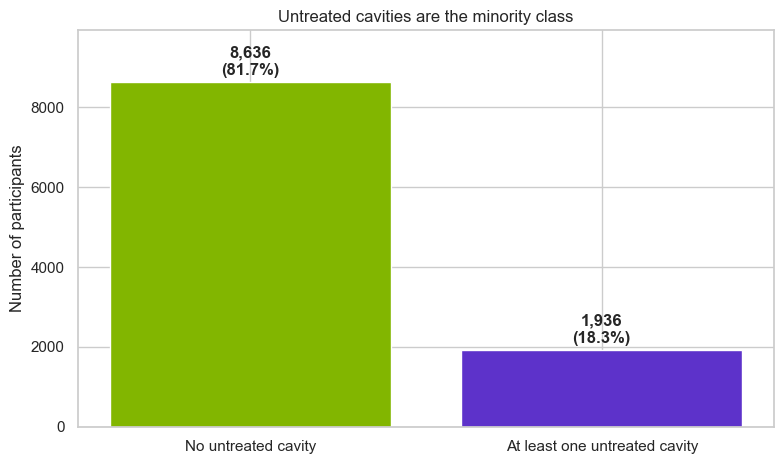

,Cavity status,Participants,Percent
0,No untreated cavity,8636,0.816875
1,At least one untreated cavity,1936,0.183125


In [14]:
# Count both target classes and calculate their percentages.
target_summary = (
    eda["Cavity status"]
    .value_counts()
    .reindex(["No untreated cavity", "At least one untreated cavity"])
    .rename_axis("Cavity status")
    .reset_index(name="Participants")
)
target_summary["Percent"] = target_summary["Participants"] / len(eda)

plt.figure(figsize=(8, 4.8))
bars = plt.bar(
    target_summary["Cavity status"],
    target_summary["Participants"],
    color=[GREEN, PURPLE],
)

for bar, count, percent in zip(
    bars,
    target_summary["Participants"],
    target_summary["Percent"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 100,
        f"{count:,}\n({percent:.1%})",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("Number of participants")
plt.title("Untreated cavities are the minority class")
plt.ylim(0, target_summary["Participants"].max() * 1.15)
plt.tight_layout()
plt.show()

target_summary

About 18% of the training participants have at least one untreated cavity. A model that predicted *no cavity* for everyone would therefore appear to be about 82% accurate while failing to identify a single cavity case.

This is why the later notebooks will not rely on accuracy alone. ROC-AUC, precision-recall AUC, recall, and balanced accuracy will provide more useful measures of performance.

## Age

This section checks whether cavity prevalence changes across age groups.

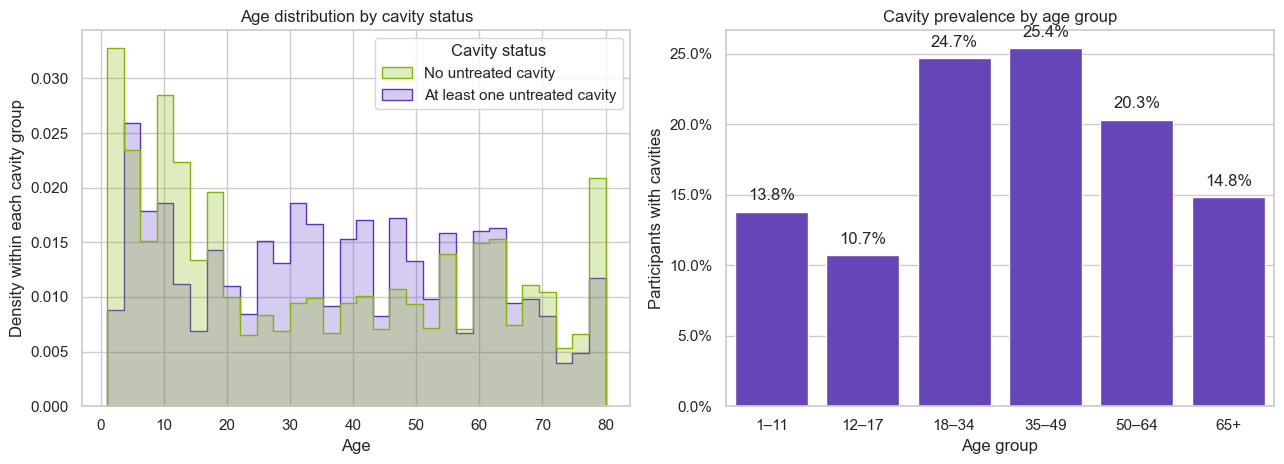

,Age group,Participants,Cavity_cases,Cavity_prevalence
0,1–11,2632,363,0.137918
1,12–17,1102,118,0.107078
2,18–34,1818,449,0.246975
3,35–49,1516,385,0.253958
4,50–64,1850,376,0.203243
5,65+,1654,245,0.148126


In [16]:
# Calculate cavity prevalence within each readable age group.
age_summary = prevalence_table(eda, "Age group", age_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Compare the shape of the age distributions without letting the larger class
# dominate simply because it contains more participants.
sns.histplot(
    data=eda,
    x="age",
    hue="Cavity status",
    hue_order=["No untreated cavity", "At least one untreated cavity"],
    palette={
        "No untreated cavity": GREEN,
        "At least one untreated cavity": PURPLE,
    },
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
    ax=axes[0],
)
axes[0].set_title("Age distribution by cavity status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density within each cavity group")

# Show the easier-to-interpret cavity percentage for each age group.
sns.barplot(
    data=age_summary,
    x="Age group",
    y="Cavity_prevalence",
    color=PURPLE,
    ax=axes[1],
)
axes[1].set_title("Cavity prevalence by age group")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Participants with cavities")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axes[1])

plt.tight_layout()
plt.show()

age_summary

Age does not have one simple linear relationship with cavities. The grouped percentages make it easier to see where prevalence rises or falls, while the overlapping distributions show that age alone cannot separate the two classes.

The spike at age 80 occurs because NHANES records everyone aged 80 or older as `80`; it does not mean that every person in that bar has the same age. The model-development notebook can still use age as a continuous variable so the models are not limited by the descriptive age-group boundaries created here.

## Income

This section checks whether cavity prevalence changes across reported income groups.

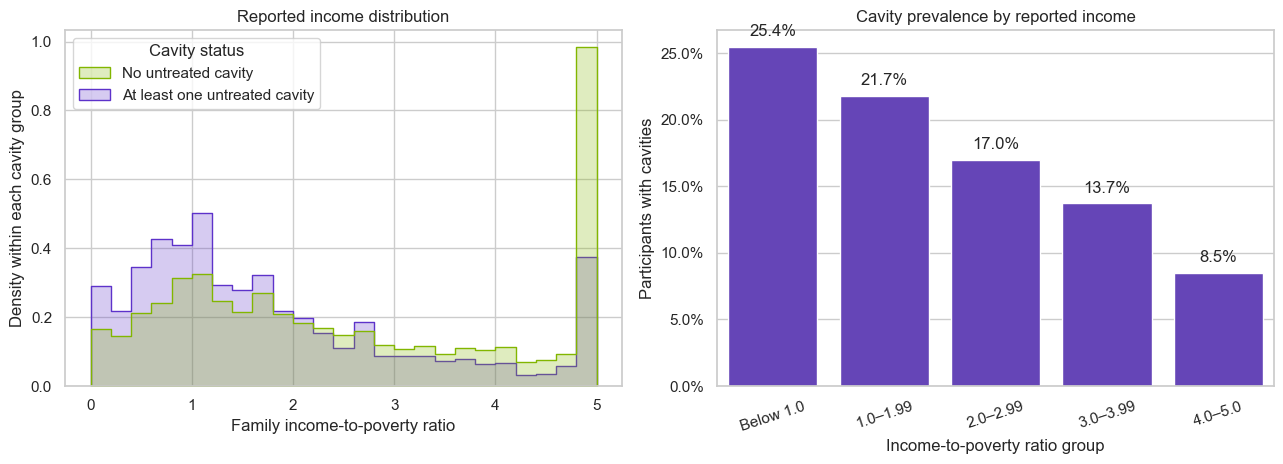

,Income group,Participants,Cavity_cases,Cavity_prevalence
0,Below 1.0,2194,558,0.254330
1,1.0–1.99,2451,533,0.217462
2,2.0–2.99,1425,242,0.169825
3,3.0–3.99,941,129,0.137088
4,4.0–5.0,2212,188,0.084991


In [21]:
# Use reported income values for the distribution and income-group comparison.
reported_income = eda.loc[eda["income_poverty_ratio"].notna()].copy()
income_summary = prevalence_table(reported_income, "Income group", income_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(
    data=reported_income,
    x="income_poverty_ratio",
    hue="Cavity status",
    hue_order=["No untreated cavity", "At least one untreated cavity"],
    palette={
        "No untreated cavity": GREEN,
        "At least one untreated cavity": PURPLE,
    },
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
    ax=axes[0],
)
axes[0].set_title("Reported income distribution")
axes[0].set_xlabel("Family income-to-poverty ratio")
axes[0].set_ylabel("Density within each cavity group")

sns.barplot(
    data=income_summary,
    x="Income group",
    y="Cavity_prevalence",
    color=PURPLE,
    ax=axes[1],
)
axes[1].set_title("Cavity prevalence by reported income")
axes[1].set_xlabel("Income-to-poverty ratio group")
axes[1].set_ylabel("Participants with cavities")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=18)
label_percent_bars(axes[1])

plt.tight_layout()
plt.show()

income_summary

The left graph's y-axis is **density**, not a raw participant count. Because the two cavity groups have very different sizes, plotting raw counts would make the smaller "at least one untreated cavity" group look tiny even if its shape is similar. Density rescales each group's histogram so the area under its curve sums to 1, letting you compare the *shapes* of the two distributions fairly.

The spike near `5` on the right side of that graph is not a real cluster of people with that exact income ratio, NHANES caps ("top-codes") the income-to-poverty ratio at `5`, so every participant whose true ratio is 5 or higher gets recorded as exactly `5`. That artificially piles many high-income participants into one bar.

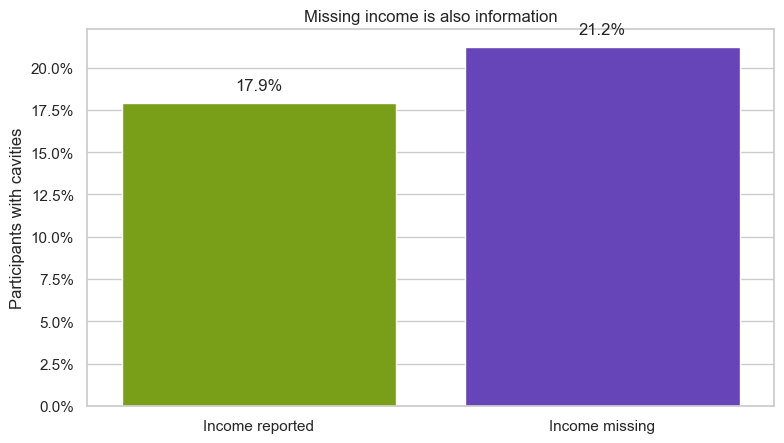

,Income response,Participants,Cavity_cases,Cavity_prevalence
0,Income reported,9223,1650,0.178901
1,Income missing,1349,286,0.212009


In [22]:
# Compare participants who reported income with those whose income is missing.
income_missing_summary = prevalence_table(
    eda,
    "Income response",
    ["Income reported", "Income missing"],
)

plt.figure(figsize=(8, 4.6))
axis = sns.barplot(
    data=income_missing_summary,
    x="Income response",
    y="Cavity_prevalence",
    palette=[GREEN, PURPLE],
    hue="Income response",
    legend=False,
)
axis.set_title("Missing income is also information")
axis.set_xlabel("")
axis.set_ylabel("Participants with cavities")
axis.yaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axis)
plt.tight_layout()
plt.show()

income_missing_summary

Reported income shows a visible socioeconomic pattern, but the distributions still overlap substantially. Income is useful context rather than a perfect separator.

Participants with missing income also have their own cavity prevalence. Preserving the missingness flag allows the model to keep that information, while the actual income value will still be imputed inside each training fold later.

## Sex and Race/Ethnicity

This section checks whether cavity prevalence differs by sex and by race/ethnicity.

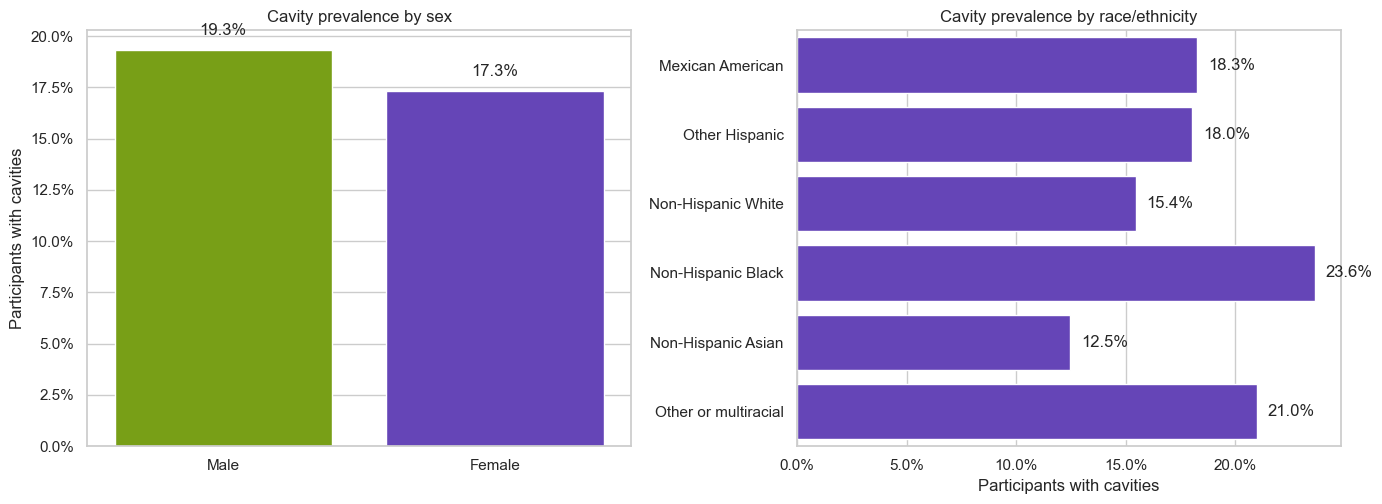

Sex summary
   Sex  Participants  Cavity_cases  Cavity_prevalence
  Male          5240          1012           0.193130
Female          5332           924           0.173293
Race/ethnicity summary


,Race/ethnicity,Participants,Cavity_cases,Cavity_prevalence
0,Mexican American,1336,244,0.182635
1,Other Hispanic,1049,189,0.180172
2,Non-Hispanic White,3515,543,0.154481
3,Non-Hispanic Black,2858,675,0.236179
4,Non-Hispanic Asian,1123,140,0.124666
5,Other or multiracial,691,145,0.209841


In [23]:
sex_summary = prevalence_table(eda, "Sex", ["Male", "Female"])
race_order = [
    "Mexican American",
    "Other Hispanic",
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Non-Hispanic Asian",
    "Other or multiracial",
]
race_summary = prevalence_table(eda, "Race/ethnicity", race_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

sns.barplot(
    data=sex_summary,
    x="Sex",
    y="Cavity_prevalence",
    palette=[GREEN, PURPLE],
    hue="Sex",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cavity prevalence by sex")
axes[0].set_xlabel("")
axes[0].set_ylabel("Participants with cavities")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axes[0])

sns.barplot(
    data=race_summary,
    y="Race/ethnicity",
    x="Cavity_prevalence",
    color=PURPLE,
    ax=axes[1],
)
axes[1].set_title("Cavity prevalence by race/ethnicity")
axes[1].set_xlabel("Participants with cavities")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axes[1], horizontal=True)

plt.tight_layout()
plt.show()

print("Sex summary")
print(sex_summary.to_string(index=False))
print("Race/ethnicity summary")
race_summary

The training data contains differences across demographic groups, but these figures do not show that sex or race biologically causes cavities. The categories can also reflect differences in healthcare access, income, environment, age distribution, and other conditions not fully measured here.

Notebook 7 will return to these groups and test whether model performance is consistent across them.

## Diabetes Status

This section checks whether cavity prevalence differs by diabetes status.

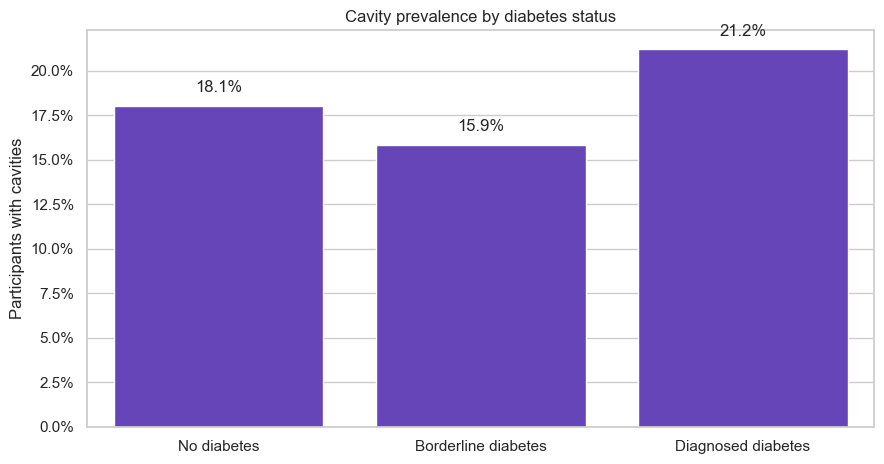

,Diabetes status,Participants,Cavity_cases,Cavity_prevalence
0,No diabetes,9346,1687,0.180505
1,Borderline diabetes,208,33,0.158654
2,Diagnosed diabetes,1018,216,0.212181


In [24]:
diabetes_order = ["No diabetes", "Borderline diabetes", "Diagnosed diabetes"]
diabetes_summary = prevalence_table(eda, "Diabetes status", diabetes_order)

plt.figure(figsize=(9, 4.8))
axis = sns.barplot(
    data=diabetes_summary,
    x="Diabetes status",
    y="Cavity_prevalence",
    color=PURPLE,
)
axis.set_title("Cavity prevalence by diabetes status")
axis.set_xlabel("")
axis.set_ylabel("Participants with cavities")
axis.yaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axis)
plt.tight_layout()
plt.show()

diabetes_summary

Diabetes status shows a group-level relationship with untreated cavities, but the groups also differ in age and other characteristics. A multivariable model is needed before deciding how much independent information diabetes contributes.

## Time Since the Last Dental Visit

This section checks whether cavity prevalence differs by how recently a participant last saw a dentist.

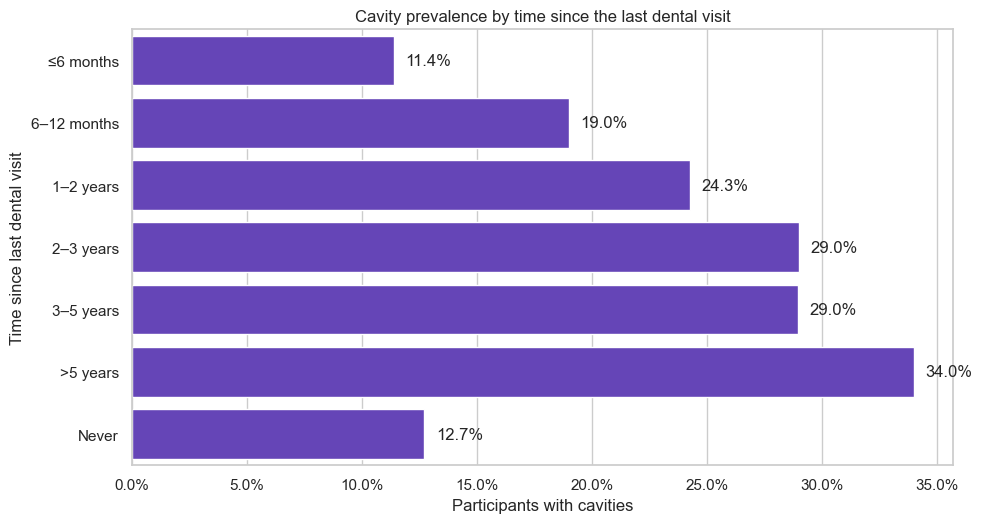

,Last dental visit,Participants,Cavity_cases,Cavity_prevalence
0,≤6 months,4925,561,0.113909
1,6–12 months,1606,305,0.189913
2,1–2 years,1207,293,0.242751
3,2–3 years,617,179,0.290113
4,3–5 years,563,163,0.289520
5,>5 years,1056,359,0.339962
6,Never,598,76,0.127090


In [26]:
dental_visit_summary = prevalence_table(
    eda,
    "Last dental visit",
    dental_visit_order,
)

plt.figure(figsize=(10, 5.4))
axis = sns.barplot(
    data=dental_visit_summary,
    y="Last dental visit",
    x="Cavity_prevalence",
    color=PURPLE,
)
axis.set_title("Cavity prevalence by time since the last dental visit")
axis.set_xlabel("Participants with cavities")
axis.set_ylabel("Time since last dental visit")
axis.xaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axis, horizontal=True)
plt.tight_layout()
plt.show()

dental_visit_summary

Prevalence generally rises as the time since the last visit increases through the `>5 years` group. The `Never` group is lower, so the pattern is not perfectly linear; that group likely has a different age distribution because it includes children who have not yet visited a dentist.

The categories still provide a useful healthcare-access signal, although this figure cannot determine whether less frequent care led to untreated cavities or whether other barriers influenced both.

## Self-Rated Teeth Condition

This section checks whether cavity prevalence differs by how participants rate the condition of their own teeth.

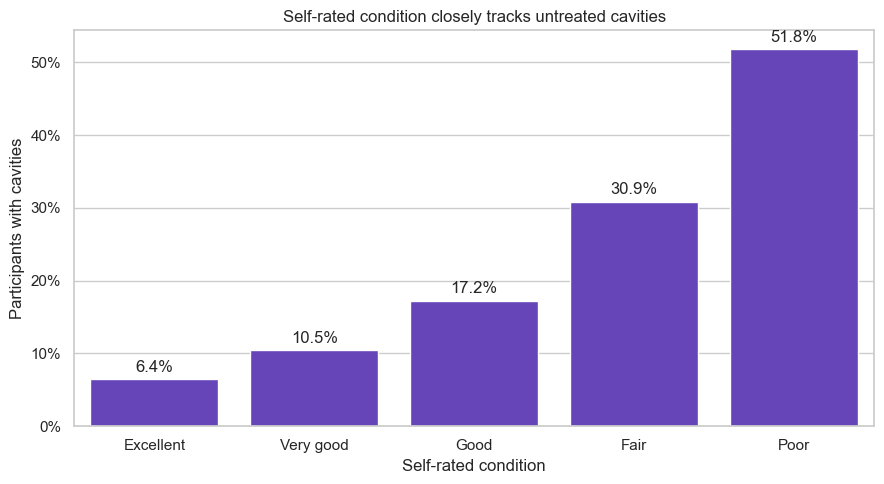

,Self-rated teeth condition,Participants,Cavity_cases,Cavity_prevalence
0,Excellent,2082,134,0.064361
1,Very good,2560,268,0.104688
2,Good,3323,573,0.172435
3,Fair,1860,574,0.308602
4,Poor,747,387,0.518072


In [27]:
teeth_condition_summary = prevalence_table(
    eda,
    "Self-rated teeth condition",
    teeth_condition_order,
)

plt.figure(figsize=(9, 5))
axis = sns.barplot(
    data=teeth_condition_summary,
    x="Self-rated teeth condition",
    y="Cavity_prevalence",
    color=PURPLE,
)
axis.set_title("Self-rated condition closely tracks untreated cavities")
axis.set_xlabel("Self-rated condition")
axis.set_ylabel("Participants with cavities")
axis.yaxis.set_major_formatter(PercentFormatter(1))
label_percent_bars(axis)
plt.tight_layout()
plt.show()

teeth_condition_summary

Self-rated teeth condition has a particularly direct relationship with the target. This makes sense because a person may already feel pain, see damage, or know that their teeth are in poor condition.

It is still a valid questionnaire predictor and is not calculated from the dental examination target. However, it is more proximal than age or income. Notebook 6 will compare model performance with and without this variable so the project is honest about how much predictive value comes from a participant already recognizing a problem.

## Correlation Overview

Correlation measures the direction and strength of a linear relationship between two numeric variables. It is useful as a summary, but it does not capture every nonlinear relationship and does not establish causation.

`SEQN` is excluded because it is only an identifier. Missing income is also left blank for this calculation rather than being imputed early.

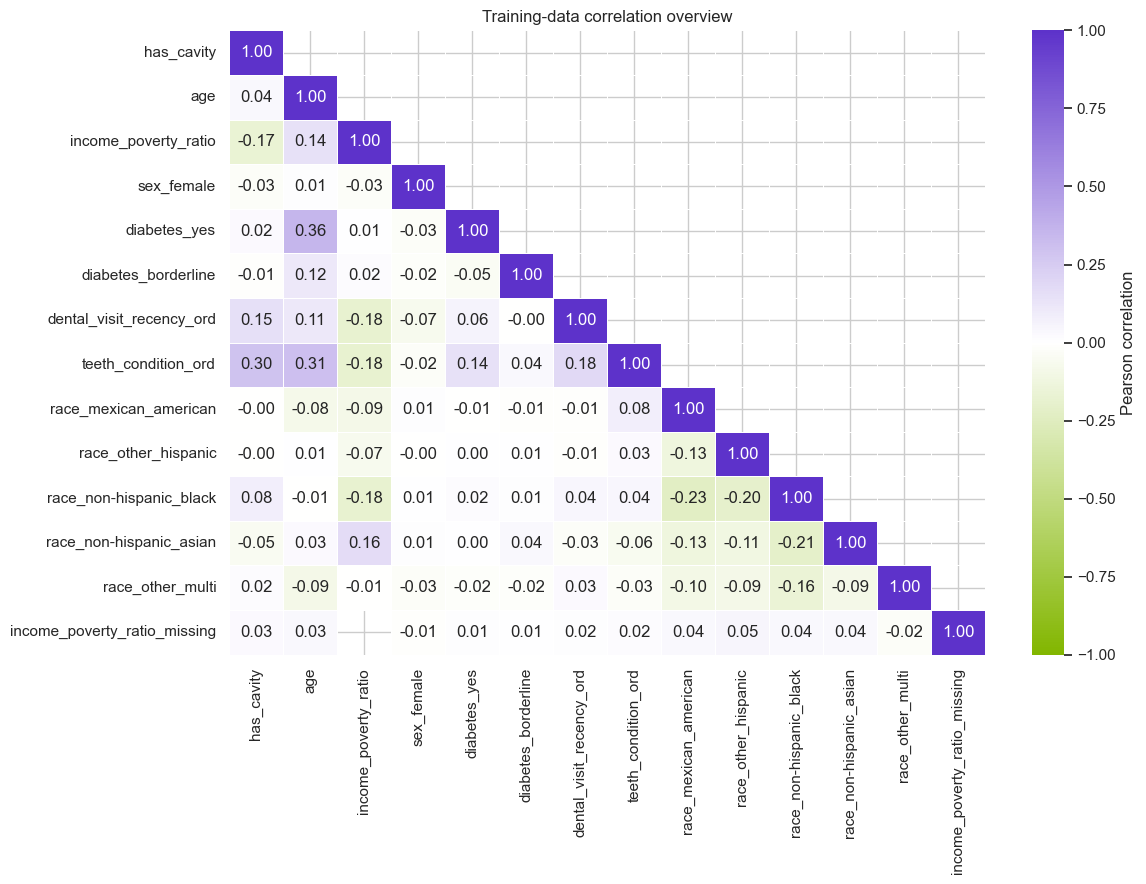

,Predictor,Correlation with has_cavity
0,teeth_condition_ord,0.296790
1,income_poverty_ratio,-0.169420
2,dental_visit_recency_ord,0.150325
3,race_non-hispanic_black,0.083494
4,race_non-hispanic_asian,-0.052107
5,age,0.038512
6,income_poverty_ratio_missing,0.028561
7,sex_female,-0.025643
8,diabetes_yes,0.024522
9,race_other_multi,0.018266


In [28]:
# Calculate correlations among the target and numeric predictors only.
correlation_columns = [
    column for column in training_data.columns
    if column != "SEQN"
]
correlations = training_data[correlation_columns].corr()

# Use the project colors with white at zero to separate positive and negative values.
correlation_cmap = LinearSegmentedColormap.from_list(
    "project_diverging",
    [GREEN, "white", PURPLE],
)
mask = np.triu(np.ones_like(correlations, dtype=bool), k=1)

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlations,
    mask=mask,
    cmap=correlation_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Training-data correlation overview")
plt.tight_layout()
plt.show()

# Rank simple linear associations with the target for easier reading.
target_correlations = (
    correlations["has_cavity"]
    .drop("has_cavity")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("Correlation with has_cavity")
    .reset_index()
    .rename(columns={"index": "Predictor"})
)

target_correlations

The correlation ranking supports the earlier plots: some predictors have visible relationships with cavities, but no single variable completely determines the outcome. Tree-based models may also find nonlinear patterns and interactions that this heatmap cannot show.

The heatmap is descriptive only. It will not be used to remove predictors before cross-validation.

## Main Findings

This section pulls the single highest-prevalence value from each of the group summaries computed above into one compact table. It is meant as a quick reference for the rest of the notebook, not as a new analysis.

In [30]:
# Collect several central observations directly from the training summaries.
highest_age = age_summary.loc[age_summary["Cavity_prevalence"].idxmax()]
lowest_income = income_summary.loc[income_summary["Cavity_prevalence"].idxmax()]
least_recent_visit = dental_visit_summary.loc[
    dental_visit_summary["Cavity_prevalence"].idxmax()
]
worst_teeth = teeth_condition_summary.loc[
    teeth_condition_summary["Cavity_prevalence"].idxmax()
]

main_findings = pd.DataFrame(
    {
        "Finding": [
            "Training-set cavity prevalence",
            "Age group with highest observed prevalence",
            "Reported-income group with highest observed prevalence",
            "Dental-visit group with highest observed prevalence",
            "Self-rated condition with highest observed prevalence",
            "Training participants with missing income",
        ],
        "Result": [
            f"{training_data['has_cavity'].mean():.1%}",
            f"{highest_age['Age group']} ({highest_age['Cavity_prevalence']:.1%})",
            f"{lowest_income['Income group']} ({lowest_income['Cavity_prevalence']:.1%})",
            f"{least_recent_visit['Last dental visit']} ({least_recent_visit['Cavity_prevalence']:.1%})",
            f"{worst_teeth['Self-rated teeth condition']} ({worst_teeth['Cavity_prevalence']:.1%})",
            f"{training_data['income_poverty_ratio'].isna().sum():,}",
        ],
    }
)

main_findings

,Finding,Result
0,Training-set cavity prevalence,18.3%
1,Age group with highest observed prevalence,35–49 (25.4%)
2,Reported-income group with highest observed pr...,Below 1.0 (25.4%)
3,Dental-visit group with highest observed preva...,>5 years (34.0%)
4,Self-rated condition with highest observed pre...,Poor (51.8%)
5,Training participants with missing income,"1,349"


## Conclusion

The training data is suitable for model development, but the exploration identifies several issues that the later notebooks must handle carefully:

1. Untreated cavities are the minority class, so accuracy alone will be misleading.
2. Age, income, healthcare access, diabetes status, and demographic groups show descriptive differences in cavity prevalence.
3. Self-rated teeth condition has an especially close relationship with the target and should receive a separate sensitivity analysis.
4. Income remains the only predictor with missing values and must be imputed inside each training fold.
5. The observed percentages describe this analytic training cohort. Without NHANES survey-weighted analysis, they should not be presented as national prevalence estimates.
6. None of these relationships establish causation.

The permanent training and test files are now saved. Notebook 4 can use `training_data.csv` for cross-validated model development without touching the held-out test set.